# Image Classification on Intel Image Dataset — CNN vs. VGG16 vs. MobileNetV2

**Dataset:** [Intel Image Classification](https://www.kaggle.com/datasets/puneet6060/intel-image-classification)
(6 classes: buildings, forest, glacier, mountain, sea, street)

**Objective:** Train and compare three architectures — a small baseline CNN,
VGG16 (transfer learning) and MobileNetV2 (transfer learning) — on the same
multi-class image classification task, then evaluate them not just on
accuracy but on parameter count, model size, and inference speed. This is
the basis for a size-vs-accuracy trade-off discussion (baseline vs. heavy
vs. edge-friendly).

**Pipeline:** Dataset (kagglehub) → Preprocessing → Augmentation →
Model 1 (Baseline CNN) → Model 2 (VGG16) → Model 3 (MobileNetV2) →
Evaluation → Confusion Matrices → Error Analysis → Comparison Table → Conclusion

## 1. Setup

In [1]:

!pip install -q kagglehub

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub

from tensorflow.keras import layers, models
from tensorflow.keras.utils import image_dataset_from_directory

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("TensorFlow Version:", tf.__version__)
print("-" * 60)

TensorFlow Version: 2.20.0
------------------------------------------------------------


## 2. Dataset

In [2]:

path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Path to dataset files:", path)
print(os.listdir(path))

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Path to dataset files: /kaggle/input/intel-image-classification
['seg_train', 'seg_pred', 'seg_test']


In [3]:

# The Intel dataset ships with seg_train/seg_train/<class>/ and
# seg_test/seg_test/<class>/ subfolders. seg_pred is unlabeled and unused here.

def find_dir(root, target_name):
    for dirpath, dirnames, filenames in os.walk(root):
        if os.path.basename(dirpath) == target_name:
            return dirpath
    return None

TRAIN_DIR = find_dir(path, "seg_train")
TEST_DIR = find_dir(path, "seg_test")

# seg_train/seg_train is the actual class-folder level (Kaggle nests it once)
TRAIN_DIR = os.path.join(TRAIN_DIR, "seg_train") if os.path.isdir(os.path.join(TRAIN_DIR, "seg_train")) else TRAIN_DIR
TEST_DIR = os.path.join(TEST_DIR, "seg_test") if os.path.isdir(os.path.join(TEST_DIR, "seg_test")) else TEST_DIR

print("Train dir:", TRAIN_DIR)
print("Test dir:", TEST_DIR)
print("Classes:", sorted(os.listdir(TRAIN_DIR)))

Train dir: /kaggle/input/intel-image-classification/seg_train/seg_train
Test dir: /kaggle/input/intel-image-classification/seg_test/seg_test
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [4]:

class_names_found = sorted([
    d for d in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, d))
])

print("Number of classes:", len(class_names_found))
for class_name in class_names_found:
    train_count = len(os.listdir(os.path.join(TRAIN_DIR, class_name)))
    test_count = len(os.listdir(os.path.join(TEST_DIR, class_name)))
    print(f"{class_name:12s} train={train_count:5d}  test={test_count:5d}")
print("-" * 60)

Number of classes: 6
buildings    train= 2191  test=  437
forest       train= 2271  test=  474
glacier      train= 2404  test=  553
mountain     train= 2512  test=  525
sea          train= 2274  test=  510
street       train= 2382  test=  501
------------------------------------------------------------


## 3. Data Preprocessing

In [5]:

IMG_SIZE = (150, 150)   # Intel images are natively ~150x150; keeping native size is faster
BATCH_SIZE = 32
SEED = 42
NUM_CLASSES = len(class_names_found)

train_ds_full = image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.15,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

val_ds = image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.15,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int"
)

test_ds = image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

class_names = train_ds_full.class_names
print("Classes:", class_names)
print("Train batches:", len(train_ds_full))
print("Val batches:", len(val_ds))
print("Test batches:", len(test_ds))

AUTOTUNE = tf.data.AUTOTUNE
train_ds_full = train_ds_full.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

Found 14034 files belonging to 6 classes.
Using 11929 files for training.
Found 14034 files belonging to 6 classes.
Using 2105 files for validation.
Found 3000 files belonging to 6 classes.
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Train batches: 373
Val batches: 66
Test batches: 94


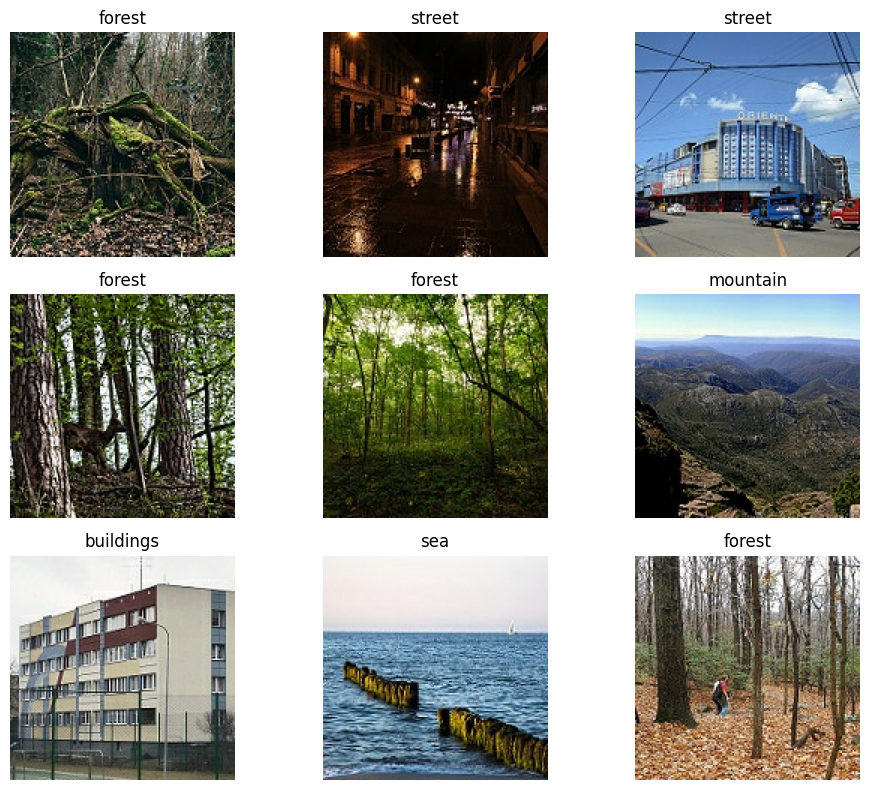

In [6]:

plt.figure(figsize=(10, 8))
for images, labels in train_ds_full.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy()])
        plt.axis("off")
plt.tight_layout()
plt.show()

## 4. Data Augmentation

In [7]:

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="data_augmentation")

## 5. Three Models

We train three architectures on identical data splits so the comparison is
fair:

1. **Baseline CNN** — a small custom convolutional network trained from
   scratch. Establishes a lower bound / sanity check.
2. **VGG16 (transfer learning)** — a large, well-known pretrained backbone
   with the convolutional base frozen.
3. **MobileNetV2 (transfer learning)** — a lightweight pretrained backbone
   designed for mobile/edge deployment, frozen convolutional base.

A shared helper trains and evaluates each model consistently, and records
accuracy, parameter count, saved model size on disk, and per-image inference
time, so the numbers are directly comparable.

In [8]:

EPOCHS = 10
results_summary = {}
histories = {}
trained_models = {}

def compile_and_train(model, name):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )
    print(f"\n{'='*60}\nTraining: {name}\n{'='*60}")
    history = model.fit(
        train_ds_full,
        validation_data=val_ds,
        epochs=EPOCHS
    )
    histories[name] = history
    trained_models[name] = model
    return history

def measure_inference_time(model, dataset, n_batches=5):
    # Warm-up
    for images, _ in dataset.take(1):
        model.predict(images, verbose=0)
    times = []
    count = 0
    for images, _ in dataset.take(n_batches):
        start = time.perf_counter()
        model.predict(images, verbose=0)
        elapsed = time.perf_counter() - start
        times.append(elapsed / images.shape[0])
        count += 1
    return float(np.mean(times)) * 1000  # ms per image

def evaluate_and_record(model, name, save_path):
    test_results = model.evaluate(test_ds, verbose=0)
    test_loss, test_acc = test_results[0], test_results[1]

    model.save(save_path)
    size_mb = os.path.getsize(save_path) / (1024 * 1024)

    n_params = model.count_params()
    inference_ms = measure_inference_time(model, test_ds)

    results_summary[name] = {
        "Test Accuracy": test_acc,
        "Parameters": n_params,
        "Model Size (MB)": size_mb,
        "Inference (ms/image)": inference_ms
    }

    print(f"{name}: test_accuracy={test_acc:.4f}, params={n_params:,}, "
          f"size={size_mb:.2f} MB, inference={inference_ms:.2f} ms/image")

    return test_acc

### Model 1 — Baseline CNN (trained from scratch)

In [9]:

def build_baseline_cnn():
    model = models.Sequential([
        layers.Input(shape=(150, 150, 3)),
        data_augmentation,
        layers.Rescaling(1./255),

        layers.Conv2D(32, 3, activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, activation="relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, activation="relu"),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation="softmax")
    ], name="baseline_cnn")
    return model

cnn_model = build_baseline_cnn()
cnn_model.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,829,126 (18.42 MB)

 Trainable params: 4,829,126 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history_cnn = compile_and_train(cnn_model, "Baseline CNN")


Training: Baseline CNN
Epoch 1/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 36s 79ms/step - accuracy: 0.4625 - loss: 1.3526 - val_accuracy: 0.6019 - val_loss: 1.0753
Epoch 2/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 0.5798 - loss: 1.1171 - val_accuracy: 0.6708 - val_loss: 0.9003
Epoch 3/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 0.6266 - loss: 1.0216 - val_accuracy: 0.6637 - val_loss: 0.9147
Epoch 4/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.6368 - loss: 0.9703 - val_accuracy: 0.7036 - val_loss: 0.8088
Epoch 5/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.6634 - loss: 0.9172 - val_accuracy: 0.7059 - val_loss: 0.7933
Epoch 6/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.6789 - loss: 0.8868 - val_accuracy: 0.7088 - val_loss: 0.8051
Epoch 7/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 0.6830 - loss: 0.8828 - val_accuracy: 0.7306 - val_loss: 0.7310
Epoch 8/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 

In [11]:
_ = evaluate_and_record(cnn_model, "Baseline CNN", "/content/model_cnn.keras")

Baseline CNN: test_accuracy=0.7343, params=4,829,126, size=55.32 MB, inference=2.77 ms/image


### Model 2 — VGG16 (transfer learning)

In [12]:


def build_vgg16():
    base_model = tf.keras.applications.VGG16(
        weights="imagenet",
        include_top=False,
        input_shape=(150, 150, 3)
    )
    base_model.trainable = False

    model = models.Sequential([
        layers.Input(shape=(150, 150, 3)),
        data_augmentation,
        layers.Lambda(tf.keras.applications.vgg16.preprocess_input),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation="softmax")
    ], name="vgg16_transfer")
    return model

vgg16_model = build_vgg16()
vgg16_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,558 (56.64 MB)

 Trainable params: 132,870 (519.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [13]:
history_vgg16 = compile_and_train(vgg16_model, "VGG16")


Training: VGG16
Epoch 1/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 40s 98ms/step - accuracy: 0.5634 - loss: 2.6840 - val_accuracy: 0.8504 - val_loss: 0.6556
Epoch 2/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 33s 89ms/step - accuracy: 0.7571 - loss: 1.0969 - val_accuracy: 0.8812 - val_loss: 0.5114
Epoch 3/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 34s 90ms/step - accuracy: 0.7963 - loss: 0.8032 - val_accuracy: 0.8888 - val_loss: 0.4494
Epoch 4/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 34s 91ms/step - accuracy: 0.8104 - loss: 0.6448 - val_accuracy: 0.8931 - val_loss: 0.4040
Epoch 5/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 33s 90ms/step - accuracy: 0.8259 - loss: 0.5560 - val_accuracy: 0.8993 - val_loss: 0.3788
Epoch 6/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 34s 91ms/step - accuracy: 0.8354 - loss: 0.5026 - val_accuracy: 0.8969 - val_loss: 0.3708
Epoch 7/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 33s 90ms/step - accuracy: 0.8433 - loss: 0.4583 - val_accuracy: 0.8979 - val_loss: 0.3512
Epoch 8/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 34s 90ms/step - accuracy: 0.8432 

In [14]:
_ = evaluate_and_record(vgg16_model, "VGG16", "/content/model_vgg16.keras")

VGG16: test_accuracy=0.8997, params=14,847,558, size=57.75 MB, inference=4.97 ms/image


### Model 3 — MobileNetV2 (transfer learning)

MobileNetV2 is included specifically as the edge/TinyML-friendly candidate —
it uses depthwise separable convolutions to cut parameter count and
inference cost dramatically compared to VGG16, which matters for
deployment on resource-constrained devices.

In [15]:

def build_mobilenetv2():
    base_model = tf.keras.applications.MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(150, 150, 3)
    )
    base_model.trainable = False

    model = models.Sequential([
        layers.Input(shape=(150, 150, 3)),
        data_augmentation,
        layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation="softmax")
    ], name="mobilenetv2_transfer")
    return model

mobilenet_model = build_mobilenetv2()
mobilenet_model.summary()

/tmp/ipykernel_1613/2651964674.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,462 (9.87 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [16]:
history_mobilenet = compile_and_train(mobilenet_model, "MobileNetV2")


Training: MobileNetV2
Epoch 1/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.6887 - loss: 0.8536 - val_accuracy: 0.8684 - val_loss: 0.3742
Epoch 2/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - accuracy: 0.8222 - loss: 0.4911 - val_accuracy: 0.8836 - val_loss: 0.3282
Epoch 3/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.8452 - loss: 0.4337 - val_accuracy: 0.8855 - val_loss: 0.3084
Epoch 4/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - accuracy: 0.8530 - loss: 0.4064 - val_accuracy: 0.8884 - val_loss: 0.3024
Epoch 5/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 20s 37ms/step - accuracy: 0.8639 - loss: 0.3761 - val_accuracy: 0.8922 - val_loss: 0.2864
Epoch 6/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.8674 - loss: 0.3627 - val_accuracy: 0.8926 - val_loss: 0.2909
Epoch 7/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.8763 - loss: 0.3451 - val_accuracy: 0.8983 - val_loss: 0.2863
Epoch 8/10
373/373 ━━━━━━━━━━━━━━━━━━━━ 21s 37ms/step - accuracy: 0

In [17]:
_ = evaluate_and_record(mobilenet_model, "MobileNetV2", "/content/model_mobilenet.keras")

MobileNetV2: test_accuracy=0.8970, params=2,587,462, size=12.96 MB, inference=3.63 ms/image


## 6. Training Curves (all three models)

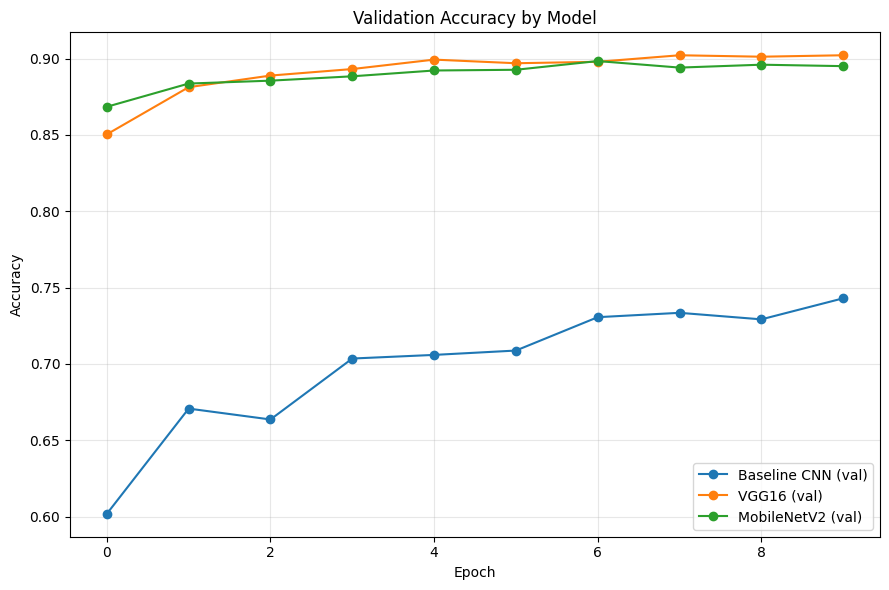

In [18]:

plt.figure(figsize=(9, 6))
for name, history in histories.items():
    plt.plot(history.history["val_accuracy"], marker="o", label=f"{name} (val)")
plt.title("Validation Accuracy by Model")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/content/val_accuracy_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

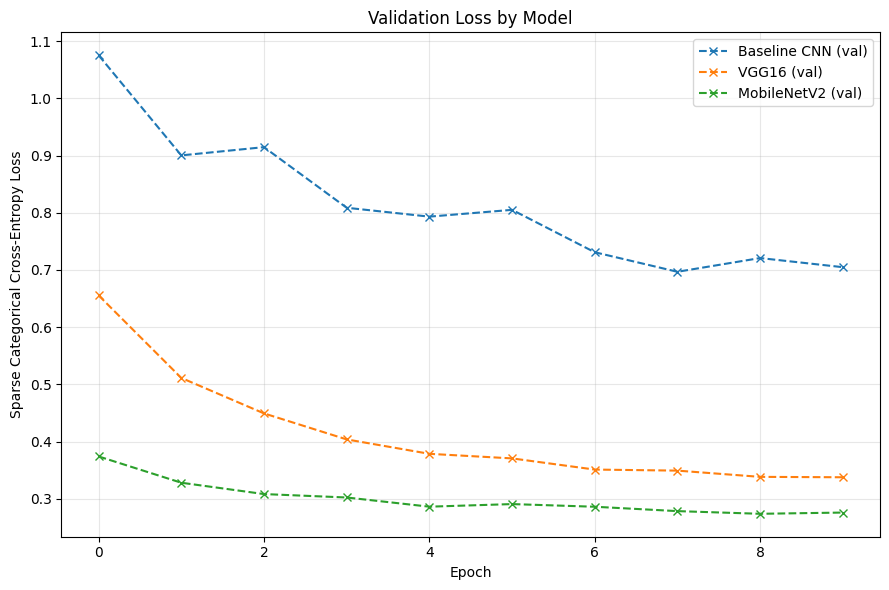

In [19]:


plt.figure(figsize=(9, 6))
for name, history in histories.items():
    plt.plot(history.history["val_loss"], marker="x", linestyle="--", label=f"{name} (val)")
plt.title("Validation Loss by Model")
plt.xlabel("Epoch")
plt.ylabel("Sparse Categorical Cross-Entropy Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/content/val_loss_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Confusion Matrices

A confusion matrix is produced for each model on the held-out **test** set
(`seg_test`), not just validation, since that's the fairer comparison point.

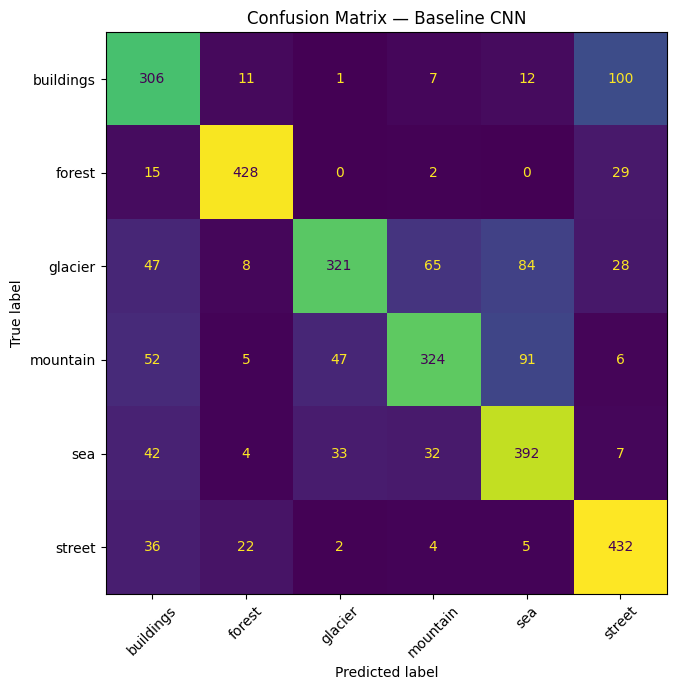

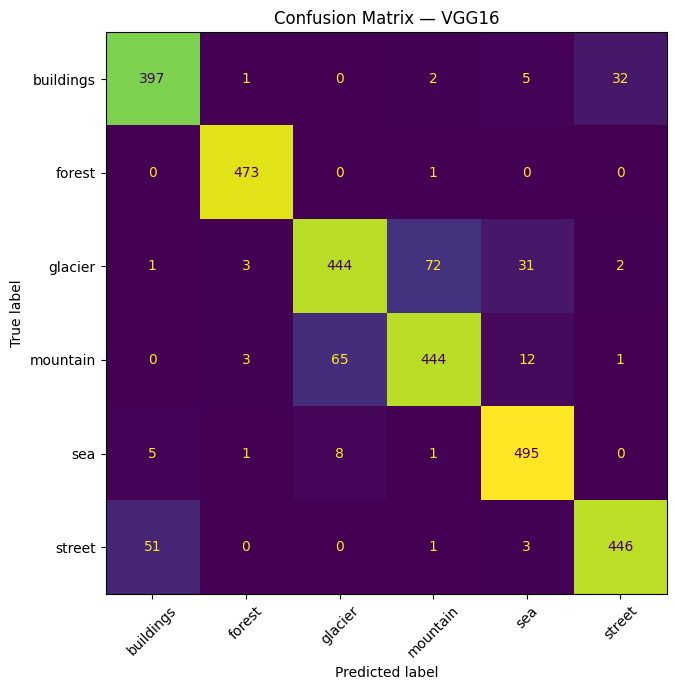

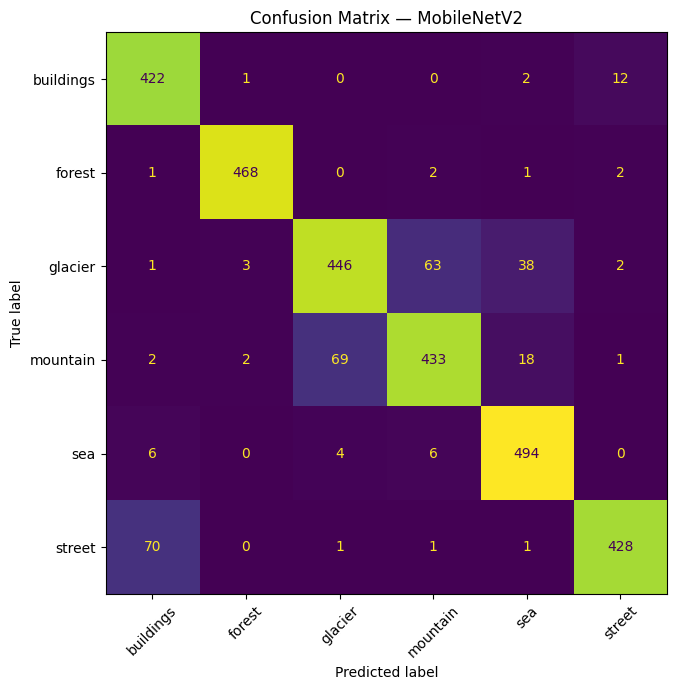

In [20]:

def get_predictions(model, dataset):
    y_true, y_pred = [], []
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(labels.numpy())
    return np.array(y_true), np.array(y_pred)

predictions_store = {}

for name, model in trained_models.items():
    y_true, y_pred = get_predictions(model, test_ds)
    predictions_store[name] = (y_true, y_pred)

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

    fig, ax = plt.subplots(figsize=(7, 7))
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
    plt.title(f"Confusion Matrix — {name}")
    plt.tight_layout()
    plt.savefig(f"/content/confusion_matrix_{name.replace(' ', '_').lower()}.png", dpi=300, bbox_inches="tight")
    plt.show()

In [21]:

for name, (y_true, y_pred) in predictions_store.items():
    print(f"\n{'='*60}\n{name}\n{'='*60}")
    print(classification_report(y_true, y_pred, target_names=class_names))


Baseline CNN
              precision    recall  f1-score   support

   buildings       0.61      0.70      0.65       437
      forest       0.90      0.90      0.90       474
     glacier       0.79      0.58      0.67       553
    mountain       0.75      0.62      0.68       525
         sea       0.67      0.77      0.72       510
      street       0.72      0.86      0.78       501

    accuracy                           0.73      3000
   macro avg       0.74      0.74      0.73      3000
weighted avg       0.74      0.73      0.73      3000


VGG16
              precision    recall  f1-score   support

   buildings       0.87      0.91      0.89       437
      forest       0.98      1.00      0.99       474
     glacier       0.86      0.80      0.83       553
    mountain       0.85      0.85      0.85       525
         sea       0.91      0.97      0.94       510
      street       0.93      0.89      0.91       501

    accuracy                           0.90      3000
  

## 8. Error Analysis

Misclassified test images from the **best-performing model**, with the
model's predicted class, the true class, and its confidence score.

Best model by test accuracy: VGG16


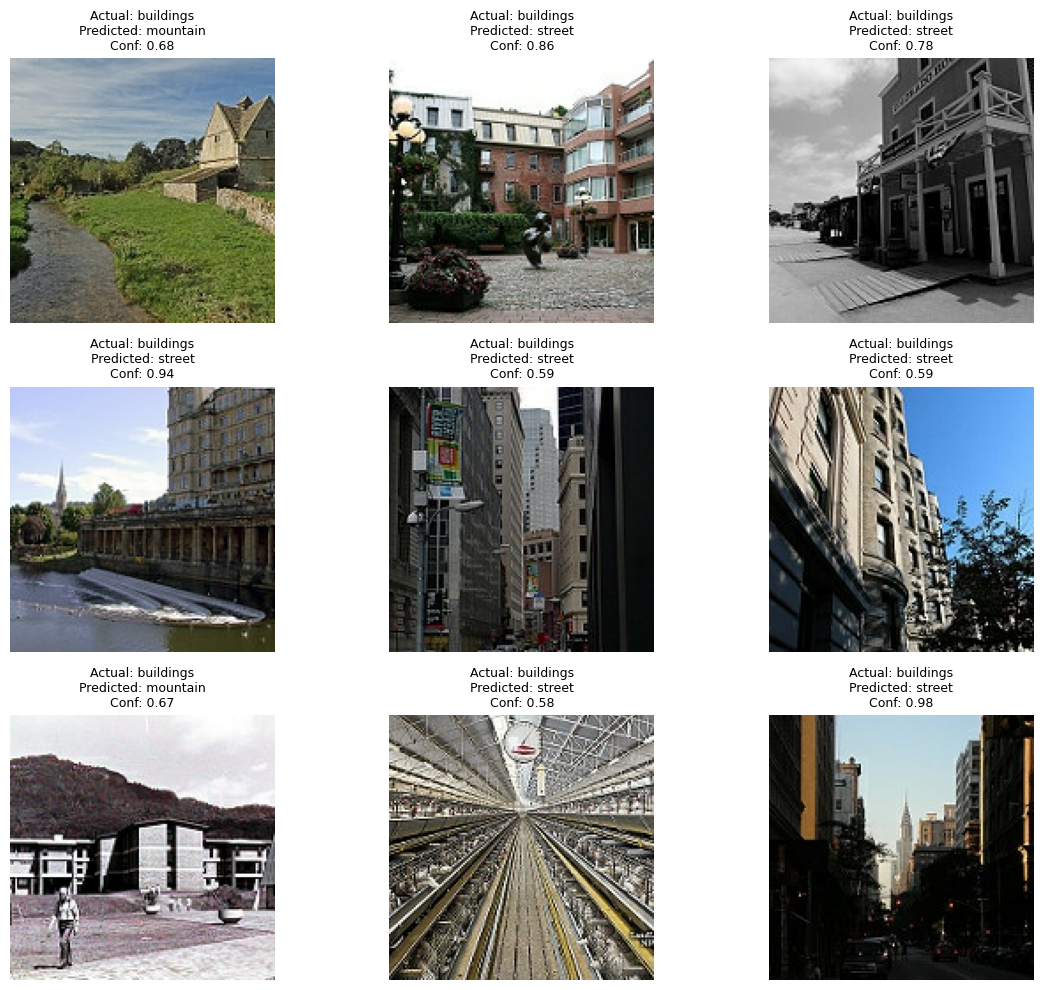

Displayed 9 incorrect predictions from VGG16.


In [22]:

best_model_name = max(results_summary, key=lambda k: results_summary[k]["Test Accuracy"])
best_model = trained_models[best_model_name]
print(f"Best model by test accuracy: {best_model_name}")

plt.figure(figsize=(12, 10))
shown = 0

for images, labels in test_ds:
    preds = best_model.predict(images, verbose=0)
    predicted_classes = np.argmax(preds, axis=1)
    true_classes = labels.numpy()

    for i in range(len(images)):
        if predicted_classes[i] != true_classes[i] and shown < 9:
            plt.subplot(3, 3, shown + 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            actual = class_names[true_classes[i]]
            predicted = class_names[predicted_classes[i]]
            confidence = preds[i][predicted_classes[i]]
            plt.title(f"Actual: {actual}\nPredicted: {predicted}\nConf: {confidence:.2f}", fontsize=9)
            plt.axis("off")
            shown += 1
    if shown >= 9:
        break

plt.tight_layout()
plt.savefig("/content/error_analysis.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Displayed {shown} incorrect predictions from {best_model_name}.")

**Discuss here, based on what you actually observe in the grid above:**
which classes get confused with each other most often (check the confusion
matrix off-diagonal cells), and what visual traits the misclassified images
seem to share (lighting, occlusion, ambiguous scenes — e.g. glacier vs.
mountain, or sea vs. glacier, are common Intel-dataset confusions, but only
state what your own results show).

## 9. Final Comparison Table

In [23]:

results_df = pd.DataFrame(results_summary).T
results_df["Test Accuracy"] = (results_df["Test Accuracy"] * 100).round(2)
results_df["Parameters"] = results_df["Parameters"].apply(lambda x: f"{x/1e6:.2f}M")
results_df["Model Size (MB)"] = results_df["Model Size (MB)"].round(2)
results_df["Inference (ms/image)"] = results_df["Inference (ms/image)"].round(2)

results_df = results_df.rename(columns={"Test Accuracy": "Test Accuracy (%)"})
results_df = results_df[["Test Accuracy (%)", "Parameters", "Model Size (MB)", "Inference (ms/image)"]]

print(results_df.to_string())
results_df.to_csv("/content/results_comparison.csv")
results_df

              Test Accuracy (%) Parameters  Model Size (MB)  Inference (ms/image)
Baseline CNN              73.43      4.83M            55.32                  2.77
VGG16                     89.97     14.85M            57.75                  4.97
MobileNetV2               89.70      2.59M            12.96                  3.63


,Test Accuracy (%),Parameters,Model Size (MB),Inference (ms/image)
Baseline CNN,73.43,4.83M,55.32,2.77
VGG16,89.97,14.85M,57.75,4.97
MobileNetV2,89.70,2.59M,12.96,3.63


## 10. Conclusion

_Fill this in using your actual numbers from the table above — do not reuse
the example figures from planning notes. A conclusion in this style is
appropriate only if your results support it:_

> MobileNetV2 achieved [accuracy]% test accuracy versus VGG16's [accuracy]%,
> while using roughly [X]× fewer parameters and running [Y]× faster per
> image — making it the more practical choice for resource-constrained or
> edge deployment, at a [small/moderate/significant] cost in accuracy
> relative to VGG16. The baseline CNN, trained from scratch, achieved
> [accuracy]%, [confirming/not confirming] the benefit of transfer learning
> on this dataset size.

### Limitations
- All three models were evaluated with frozen pretrained backbones (no fine-tuning of VGG16/MobileNetV2 layers).
- Trained for a fixed 10 epochs each; relative rankings could shift with longer training or learning-rate tuning.
- Inference timing was measured in a Colab GPU/CPU session and will differ from an actual edge device.

### Future Work
- Fine-tune the top layers of VGG16 and MobileNetV2 and re-compare.
- Quantize MobileNetV2 (e.g. TFLite) and re-measure size/inference for a true edge-deployment number.
- Try a validation curve over training epochs to check for overfitting per model.